# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

Before you start, install the some of the required packages. 

In [28]:
!python -m pip install kaggle==1.6.12

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.7/79.7 kB 1.4 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.3/163.3 kB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.2/78.2 kB 15.0 MB/s eta 0:00:00
  Created wheel for kaggle: filename=kaggle-1.6.12-py3-none-any.whl size=102969 sha256=f53982c838fbac4687c1d31a80e3be346cc30d8cfd9453dbe64aac7cc129f355
  Stored in directory: /home/student/.cache/pip/wheels/1e/0b/7c/50f8e89c3d2f82838dbd7afeddffbb9357003009ada98216c7
Successfully built kaggle
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
!pip install --target=/workspace ucimlrepo numpy==1.24.3 fredapi

  Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)
  Using cached numpy-1.24.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
  Using cached fredapi-0.5.2-py3-none-any.whl (11 kB)
  Using cached pandas-2.3.3-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.8 MB)
  Using cached certifi-2025.10.5-py3-none-any.whl (163 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)


**Note:** Restart the kernel to use updated package(s).

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1.** Problem Statement
In 2-4 sentences, explain the kind of problem you want to look at and the datasets you will be wrangling for this project.

Finding the right datasets can be time-consuming. Here we provide you with a list of websites to start with. But we encourage you to explore more websites and find the data that interests you.

* Google Dataset Search https://datasetsearch.research.google.com/
* The U.S. Government’s open data https://data.gov/
* UCI Machine Learning Repository https://archive.ics.uci.edu/ml/index.php


### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

---
### **1.1.** Problem Statement

This project aims to explore the relationship between U.S. inflation and stock market performance over time.  
Using data obtained from the **Federal Reserve Economic Data (FRED)** API, two key datasets were collected: the **S&P 500 Index**, representing overall stock market performance, and the **Consumer Price Index (CPI)**, representing inflation levels.  
By integrating and analyzing these datasets, the study seeks to uncover potential patterns or correlations between inflation dynamics and stock market movements.  

**Research Question:**  
*How does inflation (CPI) relate to the performance of the S&P 500 Index over time?*

### 1.2. Data Gathering

For this project, I gathered two datasets related to financial and economic indicators, as I have a strong interest in the field of finance. Both datasets contain more than 500 observations, which allows for meaningful statistical and time-series analysis.


#### **Dataset 1 – S&P 500 Index**

**Type:** *CSV file*

**Method:** *Gather data by accessing APIs*  
The S&P 500 dataset was obtained programmatically from the FRED (Federal Reserve Economic Data) API using its programmatic interface.  
I chose this dataset because the S&P 500 is one of the most important indicators of the U.S. stock market performance and overall investor sentiment.  
The dataset includes two key variables:  
- **`date`** – Date of observation  
- **`SP500`** – Daily closing value of the S&P 500 index  

In [7]:
#FILL IN 1st data gathering and loading method

In [1]:
import pandas as pd
import numpy as np
from fredapi import Fred

In [2]:
# Initialize the FRED client with the API key
fred = Fred()

In [30]:
# Retrieve the S&P 500 time series data from FRED
data = fred.get_series('SP500')

# Convert to DataFrame
df = data.to_frame(name='SP500')

# Adjust the index
df.reset_index(inplace=True)
df.columns = ['date', 'SP500']

# Export to CSV file
df.to_csv('raw_data_sp500.csv', index=False)

In [3]:
# Load the dataset from the CSV file
sp500_df = pd.read_csv('raw_data_sp500.csv')

#### Dataset 2 – Consumer Price Index (CPI)

**Type:** *CSV file*

**Method:** *Gather data by accessing APIs*
The CPI dataset was also obtained from the FRED API using its programmatic interface capabilities.
I selected this dataset because inflation is a central macroeconomic variable that directly influences financial markets and monetary policy.
This dataset contains over 500 monthly observations, which makes it suitable for trend and correlation analysis.
The dataset includes two variables:

- **`date`** – Date of observation  
- **`CPI`** – U.S. Consumer Price Index for All Urban Consumers: All Items (seasonally adjusted, monthly)  

In [5]:
#FILL IN 2nd data gathering and loading method

In [32]:
# Retrieve the U.S. Consumer Price Index (CPI) time series data from FRED
data = fred.get_series('CPIAUCSL')

# Convert to DataFrame
df = data.to_frame(name='CPI')

# Adjust the index
df.reset_index(inplace=True)
df.columns = ['date', 'CPI']

# Optional: store the raw data locally as cpi_raw.csv
df.to_csv('raw_data_cpi.csv', index=False)

In [4]:
# Load the dataset from the CSV file
cpi_df = pd.read_csv('raw_data_cpi.csv')

Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [ ]:
#Optional: store the raw data in your local data store
# OK, export the raw datasets locally as sp500_raw.csv and cpi_raw.csv

## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### Quality Issue 1:

In [7]:
#FILL IN - Inspecting the dataframe visually
sp500_df.head()

,date,SP500
0,2015-11-09,2078.58
1,2015-11-10,2081.72
2,2015-11-11,2075.00
3,2015-11-12,2045.97
4,2015-11-13,2023.04


In [8]:
#FILL IN - Inspecting the dataframe programmatically
sp500_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2609 entries, 0 to 2608
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    2609 non-null   object 
 1   SP500   2514 non-null   float64
dtypes: float64(1), object(1)
memory usage: 40.9+ KB


In [9]:
sp500_df.shape

(2609, 2)

In [10]:
sp500_df.isna().sum()

date      0
SP500    95
dtype: int64

In [11]:
sp500_df.duplicated().sum()

0

Issue and justification: The `SP500` column contains 95 missing values, which may lead to incomplete time series analysis.

### Quality Issue 2:

In [12]:
#FILL IN - Inspecting the dataframe visually
cpi_df.head()

,date,CPI
0,1947-01-01,21.48
1,1947-02-01,21.62
2,1947-03-01,22.00
3,1947-04-01,22.00
4,1947-05-01,21.95


In [13]:
#FILL IN - Inspecting the dataframe programmatically
cpi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 945 entries, 0 to 944
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    945 non-null    object 
 1   CPI     945 non-null    float64
dtypes: float64(1), object(1)
memory usage: 14.9+ KB


In [14]:
cpi_df.shape

(945, 2)

In [15]:
 cpi_df.isna().sum()

date    0
CPI     0
dtype: int64

In [16]:
cpi_df.duplicated().sum()

0

Issue and justification: The `date` column in `cpi_df` and `sp500_df` is stored as an object instead of a datetime type, which may hinder time-based analysis.

### Tidiness Issue 1:

In [17]:
#FILL IN - Inspecting the dataframe visually
sp500_df.head(), sp500_df.tail()

(         date    SP500
 0  2015-11-09  2078.58
 1  2015-11-10  2081.72
 2  2015-11-11  2075.00
 3  2015-11-12  2045.97
 4  2015-11-13  2023.04,
             date    SP500
 2604  2025-10-31  6840.20
 2605  2025-11-03  6851.97
 2606  2025-11-04  6771.55
 2607  2025-11-05  6796.29
 2608  2025-11-06  6720.32)

In [18]:
sp500_df.columns

Index(['date', 'SP500'], dtype='object')

In [19]:
sp500_df.sample(5)

,date,SP500
1510,2021-08-23,4479.53
2104,2023-12-01,4594.63
2082,2023-11-01,4237.86
486,2017-09-19,2506.65
293,2016-12-22,2260.96


In [20]:
#FILL IN - Inspecting the dataframe programmatically
sp500_df.duplicated().sum()

0

In [21]:
sp500_df.nunique()

date     2609
SP500    2506
dtype: int64

In [22]:
sp500_df['date'].is_unique

True

Issue and justification: The `sp500_df.nunique()` results show a unique date per observation and slightly fewer unique S&P 500 values, which is expected due to repeated closing prices; therefore, no tidiness issues were identified.

### Tidiness Issue 2: 

In [23]:
#FILL IN - Inspecting the dataframe visually
cpi_df.head(), cpi_df.tail()

(         date    CPI
 0  1947-01-01  21.48
 1  1947-02-01  21.62
 2  1947-03-01  22.00
 3  1947-04-01  22.00
 4  1947-05-01  21.95,
            date      CPI
 940  2025-05-01  320.580
 941  2025-06-01  321.500
 942  2025-07-01  322.132
 943  2025-08-01  323.364
 944  2025-09-01  324.368)

In [24]:
cpi_df.columns

Index(['date', 'CPI'], dtype='object')

In [25]:
cpi_df.sample(5)

,date,CPI
101,1955-06-01,26.710
541,1992-02-01,138.600
591,1996-04-01,156.100
669,2002-10-01,181.200
881,2020-06-01,257.042


In [26]:
#FILL IN - Inspecting the dataframe programmatically
cpi_df.duplicated().sum()

0

In [27]:
cpi_df.nunique()

date    945
CPI     856
dtype: int64

In [28]:
cpi_df['date'].is_unique

True

Issue and justification: No tidiness issues were found, as each observation has a unique date and a single CPI value, with slight repetition in CPI values being normal for economic time series data.

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [5]:
# FILL IN - Make copies of the datasets to ensure the raw dataframes 
# are not impacted
sp500_df_cleaned = sp500_df.copy()
cpi_df_cleaned = cpi_df.copy()

### **Quality Issue 1: Missing values in sp500_df - Completeness**

In [6]:
# FILL IN - Apply the cleaning strategy
sp500_df_cleaned['SP500'] = sp500_df_cleaned['SP500'].ffill() # forward fill

In [7]:
# FILL IN - Validate the cleaning was successful
sp500_df_cleaned.isna().sum()

date     0
SP500    0
dtype: int64

Justification: Forward filling was applied to handle missing values in the `SP500` column, as it ensures continuity in the time series by carrying forward the last available observation, which is appropriate for financial data where gaps typically correspond to non-trading days.

### **Quality Issue 2: Validity**

In [8]:
#FILL IN - Apply the cleaning strategy
sp500_df_cleaned['date'] = pd.to_datetime(sp500_df_cleaned['date'])
cpi_df_cleaned['date'] = pd.to_datetime(cpi_df_cleaned['date'])

In [9]:
#FILL IN - Validate the cleaning was successful
sp500_df_cleaned.info(); cpi_df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2610 entries, 0 to 2609
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2610 non-null   datetime64[ns]
 1   SP500   2610 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 40.9 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 945 entries, 0 to 944
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    945 non-null    datetime64[ns]
 1   CPI     945 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 14.9 KB


Justification: The `date` column was converted to the `datetime64` type using `pd.to_datetime()` to enable accurate time-based analysis, sorting, and visualization of the data.

### **Tidiness Issue 1: No tidiness issues were identified in either dataset**

In [ ]:
#FILL IN - Apply the cleaning strategy

In [ ]:
#FILL IN - Validate the cleaning was successful

Justification: If multiple variables were stored in a single column, the issue could be resolved by restructuring the dataset using the `pd.melt()` function to ensure one variable per column.

### **Tidiness Issue 2: No tidiness issues were identified in either dataset**

In [ ]:
#FILL IN - Apply the cleaning strategy

In [ ]:
#FILL IN - Validate the cleaning was successful

Justification: If duplicate date entries were found, they could be addressed by removing duplicates with the `df.drop_duplicates()` method to maintain one observation per date.

### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [10]:
#FILL IN - Remove unnecessary variables and combine datasets
combined_df = pd.merge(sp500_df_cleaned, cpi_df_cleaned, on='date', how='inner')

In [13]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    86 non-null     datetime64[ns]
 1   SP500   86 non-null     float64       
 2   CPI     86 non-null     float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 2.1 KB


In [14]:
combined_df.isna().sum()

date     0
SP500    0
CPI      0
dtype: int64

## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [15]:
#FILL IN - saving data
sp500_df_cleaned.to_csv('cleaned_data_sp500.csv', index=False)
cpi_df_cleaned.to_csv('cleaned_data_cpi.csv', index=False)

## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

*Research question:* How does inflation (CPI) relate to the performance of the S&P 500 index over time?

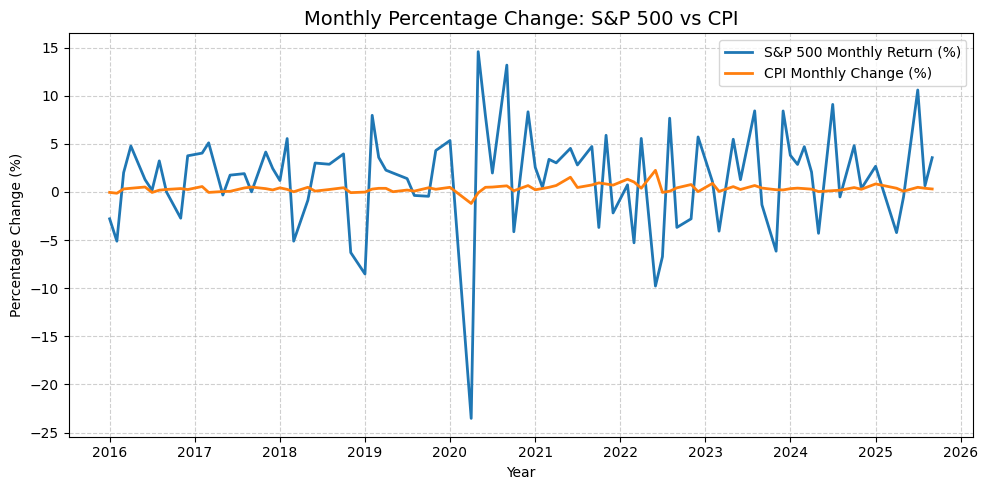

In [29]:
#Visual 1
import matplotlib.pyplot as plt

# Calculate monthly percentage returns
combined_df['SP500_return'] = combined_df['SP500'].pct_change() * 100
combined_df['CPI_change'] = combined_df['CPI'].pct_change() * 100

# Plot the percentage change series
plt.figure(figsize=(10, 5))
plt.plot(combined_df['date'], combined_df['SP500_return'], label='S&P 500 Monthly Return (%)', linewidth=2)
plt.plot(combined_df['date'], combined_df['CPI_change'], label='CPI Monthly Change (%)', linewidth=2)

plt.title('Monthly Percentage Change: S&P 500 vs CPI', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

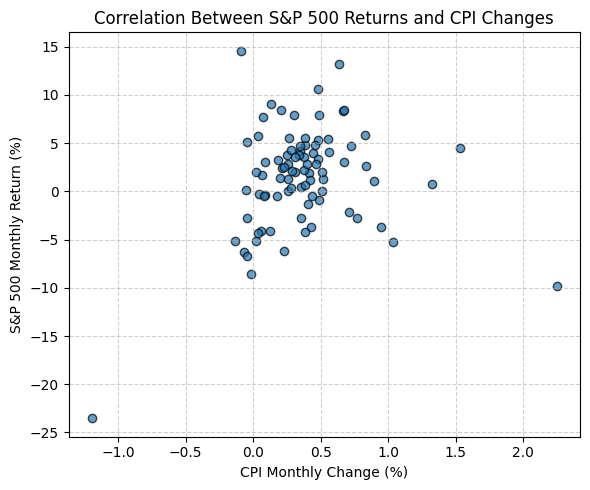

In [32]:
#Visual 2
plt.figure(figsize=(6, 5))
plt.scatter(combined_df['CPI_change'], combined_df['SP500_return'], alpha=0.7, edgecolors='k')
plt.title('Correlation Between S&P 500 Returns and CPI Changes')
plt.xlabel('CPI Monthly Change (%)')
plt.ylabel('S&P 500 Monthly Return (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

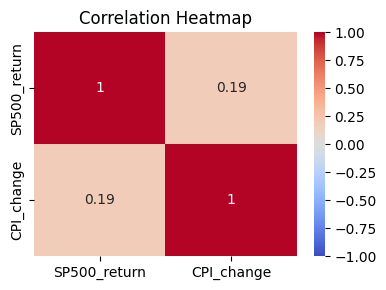

In [33]:
#Visual 3
import seaborn as sns

corr_matrix = combined_df[['SP500_return', 'CPI_change']].corr()

plt.figure(figsize=(4, 3))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Answer to research question:** 

The analysis suggests that there is **no strong linear relationship** between U.S. inflation (CPI) and the performance of the S&P 500 index over time.  
The time-series plot shows that while **CPI changes remain relatively stable**, the **S&P 500 returns fluctuate significantly**, reflecting the high volatility of the stock market compared to the gradual nature of inflation.  

The **correlation heatmap** confirms this observation, showing a **weak positive correlation of approximately 0.19** between monthly CPI changes and S&P 500 returns. This indicates that, although both variables move in the same direction occasionally, **inflation does not have a consistent or significant short-term impact on stock market returns**.  

In summary, inflation and stock market performance appear to be **largely independent in the short run**, with the S&P 500 being driven by broader economic and market-specific factors rather than monthly inflation fluctuations.


### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

*Answer:*

With more time, I would include additional economic indicators and explore lagged effects to better understand how inflation influences stock market performance.
